In [1]:
import numpy as np
import pandas as pd

import shap
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")


In [2]:
#model = joblib.load("C:/Users/Durosimi/PROJECTS/Parkinson/models/final_motor_updrs_groupcv.pkl")
data = pd.read_csv("C:/Users/Durosimi/PROJECTS/Parkinson/data/processed/features_df.csv")

In [3]:
data.columns

Index(['subject', 'test_time', 'subject.1', 'test_time.1', 'motor_updrs',
       'jitter', 'shimmer', 'hnr', 'dfa', 'rpde', 'ppe', 'age', 'sex',
       'voice_instability_mean', 'voice_instability_std',
       'jitter_shimmer_ratio', 'log_ppe', 'log_hnr', 'dysphonia_index',
       'age_jitter_interaction', 'age_shimmer_interaction', 'delta_lag_1',
       'time_diff', 'delta_trend_3', 'baseline_updrs', 'delta_motor_updrs'],
      dtype='object')

In [4]:
data["updrs_lag1"] = data.groupby("subject")["motor_updrs"].shift(1)

In [5]:
data = data.dropna(subset=["updrs_lag1"]).reset_index(drop=True)

In [6]:
data["updrs_lag1"].isna().sum()

0

In [7]:
subjects = data["subject"]

In [8]:
features = [
    "updrs_lag1",
    "baseline_updrs",
     "jitter",
    "shimmer",
    "hnr",
    "rpde",
    "ppe",
    "sex"
]

X = data[features]
y = data["delta_motor_updrs"]

### Refit the model

In [10]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=0.1))
])

In [11]:
ridge_pipeline.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge(alpha=0.1))])

In [12]:
coef = ridge_pipeline.named_steps["ridge"].coef_

coef_df = pd.DataFrame({
    "features":features,
    "coefficient": coef
}).sort_values("coefficient")

coef_df

,features,coefficient
1,baseline_updrs,-7.531999
5,rpde,-0.065514
2,jitter,-0.050231
6,ppe,-0.012053
4,hnr,-0.002602
7,sex,0.038663
3,shimmer,0.082973
0,updrs_lag1,7.673191


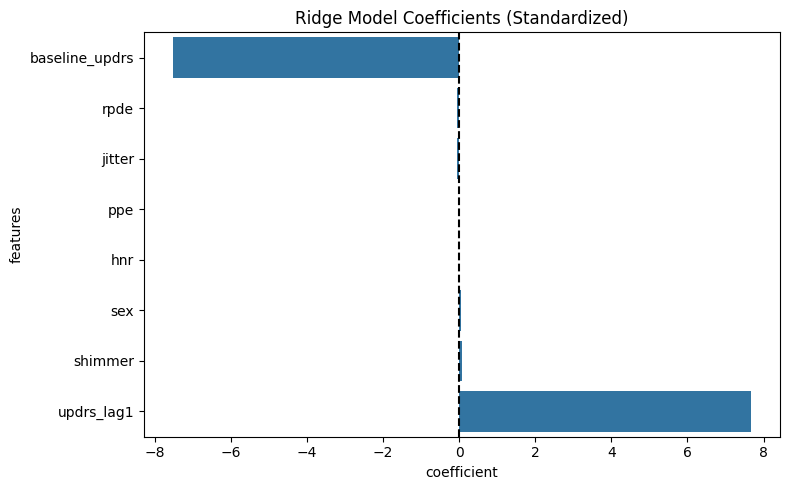

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=coef_df,
    x="coefficient",
    y="features"
)
plt.axvline(0, color="black", linestyle="--")
plt.title("Ridge Model Coefficients (Standardized)")
plt.tight_layout()
plt.show()


In [14]:
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df.sort_values("abs_coef", ascending=False)

,features,coefficient,abs_coef
0,updrs_lag1,7.673191,7.673191
1,baseline_updrs,-7.531999,7.531999
3,shimmer,0.082973,0.082973
5,rpde,-0.065514,0.065514
2,jitter,-0.050231,0.050231
7,sex,0.038663,0.038663
6,ppe,-0.012053,0.012053
4,hnr,-0.002602,0.002602


In [15]:
y_pred = ridge_pipeline.predict(X)

print("Prediction std:", np.std(y_pred))
print("Target std:", np.std(y))


Prediction std: 3.837289541020493
Target std: 4.0637163954804


In [16]:
eval_df = data[["subject", "test_time"]].copy()
eval_df["y_true"] = y.values
eval_df["y_pred"] = y_pred


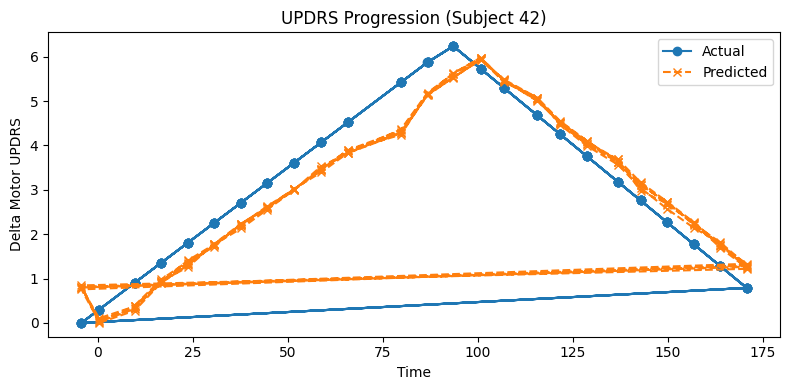

In [17]:
subject_id = eval_df["subject"].unique()[41]
patient = eval_df[eval_df["subject"] == subject_id]

plt.figure(figsize=(8,4))
plt.plot(patient["test_time"], patient["y_true"], marker="o", label="Actual")
plt.plot(patient["test_time"], patient["y_pred"], marker="x", linestyle="--", label="Predicted")
plt.title(f"UPDRS Progression (Subject {subject_id})")
plt.xlabel("Time")
plt.ylabel("Delta Motor UPDRS")
plt.legend()
plt.tight_layout()
plt.show()


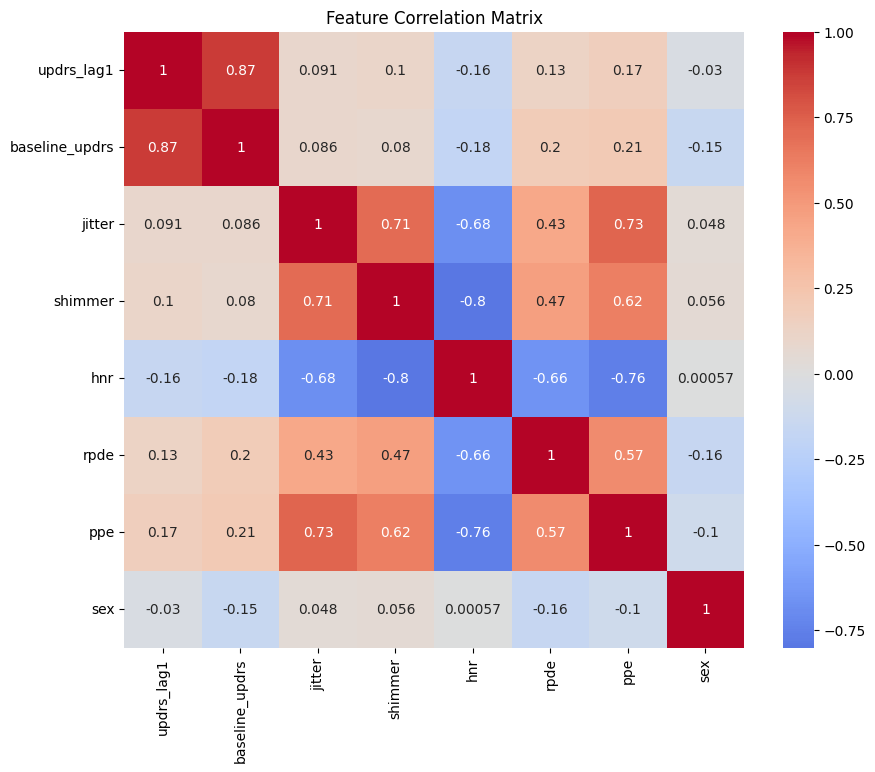

Correlation between baseline_updrs and updrs_lag1: 0.874


In [18]:
# 1. Check for multicollinearity
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = data[['updrs_lag1', 'baseline_updrs', 'jitter', 'shimmer', 'hnr', 'rpde', 'ppe', 'sex']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

# 2. Check if baseline_updrs and updrs_lag1 are highly correlated
print(f"Correlation between baseline_updrs and updrs_lag1: {data['baseline_updrs'].corr(data['updrs_lag1']):.3f}")

# 3. Check coefficient stability with different alpha values
alphas = [0.01, 0.1, 1, 10, 100]
coef_stability = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X, y)
    coef_stability.append(ridge.coef_)

In [19]:
from sklearn.model_selection import GroupKFold

coefs = []

cv = GroupKFold(n_splits=5)

for train_idx, test_idx in cv.split(X, y, groups=subjects):
    ridge_pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
    coefs.append(
        ridge_pipeline.named_steps["ridge"].coef_
    )

coef_stability = pd.DataFrame(coefs, columns=features)
coef_stability.describe()


,updrs_lag1,baseline_updrs,jitter,shimmer,hnr,rpde,ppe,sex
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,7.642835,-7.497142,-0.049088,0.080967,-0.001869,-0.063835,-0.015017,0.042480
std,0.147236,0.277590,0.020571,0.039758,0.033274,0.027304,0.047751,0.045292
min,7.436145,-7.907329,-0.081833,0.037248,-0.030256,-0.102865,-0.080533,0.007102
25%,7.543016,-7.596749,-0.051096,0.071284,-0.029518,-0.082143,-0.037505,0.027199
50%,7.704005,-7.413658,-0.044584,0.074490,-0.003137,-0.046959,-0.013751,0.027415
75%,7.755702,-7.410891,-0.042294,0.075674,0.002137,-0.046789,0.011627,0.028794
max,7.775305,-7.157082,-0.025636,0.146140,0.051429,-0.040421,0.045076,0.121890


### Model predictions were primarily driven by short-term temporal continuity and baseline disease severity, with secondary contributions from voice-derived features. The negative association between baseline severity and progression magnitude reflects regression-to-the-mean effects and is clinically plausible.

In [21]:
# explainer = shap.TreeExplainer(model.named_steps["model"])
# shap_values = explainer.shap_values(
#     model.named_steps["scaler"].transform(X)
# )

In [22]:
# shap.summary_plot(
#     shap_values,
#     model.named_steps["scaler"].transform(X),
#     feature_names=features,
#     plot_type="bar"
# )

In [23]:
# shap.summary_plot(
#     shap_values,
#     model.named_steps["scaler"].transform(X),
#     feature_names=features
# )


In [24]:
# idx = 3

# shap.force_plot(
#     explainer.expected_value,
#     shap_values[idx],
#     model.named_steps["scaler"].transform(X)[idx],
#     feature_names=features,
#     matplotlib=True
# )


In [25]:
# for feature in features:
#     shap.dependence_plot(
#         feature,
#         shap_values,
#         model.named_steps["scaler"].transform(X),
#         feature_names=features
#     )


In [26]:
# df_shap = pd.DataFrame(
#     shap_values,
#     columns=features
# )

# df_shap["sex"] = data["sex"].values

# sns.boxplot(
#     x="sex",
#     y="shimmer",
#     data=df_shap
# )
# plt.title("SHAP impact of shimmer by sex")
# plt.show()


<!-- ### SHAP analysis indicates that voice perturbation measures (jitter, shimmer, RPDE) contribute most strongly to motor UPDRS predictions. Higher jitter and shimmer values generally increase predicted motor impairment, while higher harmonic-to-noise ratio (HNR) is associated with lower predicted severity. Sex has a comparatively small but non-zero contribution. -->